# Salary prediction using POLYNOMIAL REGRESSION

### *Importing Libraries*

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

### *Load Dataset from Local directory*

In [24]:
from google.colab import files
uploaded = files.upload()

Saving Position_Salaries.csv to Position_Salaries (2).csv


### *Load Dataset*

In [25]:
dataset = pd.read_csv('Position_Salaries.csv')

### *Summarize Dataset*

In [26]:
print(dataset.shape)
print(dataset.head(5))
print(dataset.info())
print(dataset.describe())

(10, 3)
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


### *Segregate Dataset into Input X & Output Y*

In [27]:
X = dataset.iloc[:, :-1].values

In [28]:
Y = dataset.iloc[:, -1].values

### *Training Dataset using Linear Regression*

In [29]:
from sklearn.linear_model import LinearRegression
modelLR = LinearRegression()
# Convert the 'Level' column of X to a numeric format suitable for Linear Regression
X = X[:, 1].reshape(-1, 1)
modelLR.fit(X,Y)

LinearRegression()

# *Compare with Linear Regression*

In [30]:
print("Linear Regression Model Accuracy (R²):", round(modelLR.score(X,Y),4))

Linear Regression Model Accuracy (R²): 0.669


### *Visualizing Linear Regression results*

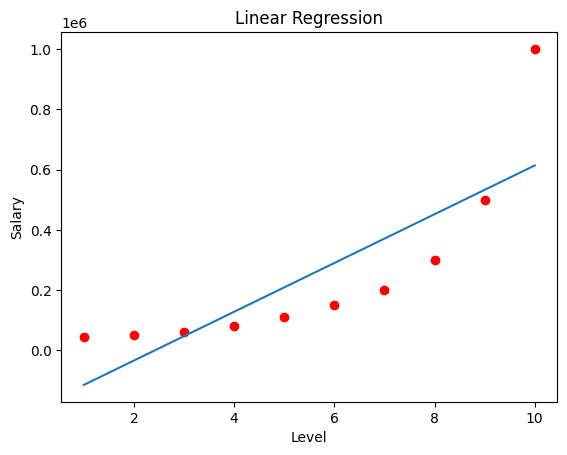

In [31]:
import matplotlib.pyplot as plt
plt.scatter(X,Y, color="red")
plt.plot(X, modelLR.predict(X))
plt.title("Linear Regression")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

### *fit() - Training Model - Calculating the initial parameters*

### *transform() - After Training we gonna transform Data by using above calculated values*

### *fit_transform() - First fit & Transform*


###*Convert X to Polynomial Format (X^n)*
###*n-degree*
###*n=2 consist x & x^2*
###*n=3 consist x & x^2 & x^3*

In [32]:
from sklearn.preprocessing import PolynomialFeatures
modelPR = PolynomialFeatures(degree = 4)
xPoly = modelPR.fit_transform(X)

###*Train same Linear Regression with X-Polynomial instead of X*

In [33]:
modelPLR = LinearRegression()
modelPLR.fit(xPoly,Y)

LinearRegression()

# *model accuracy*

In [34]:
print("Polynomial Regression Model Accuracy (R²):", round(modelPLR.score(xPoly,Y),4))

Polynomial Regression Model Accuracy (R²): 0.9974


### *Visualizing Polynomial Regression results*

/tmp/ipykernel_291/2903165934.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1,1)


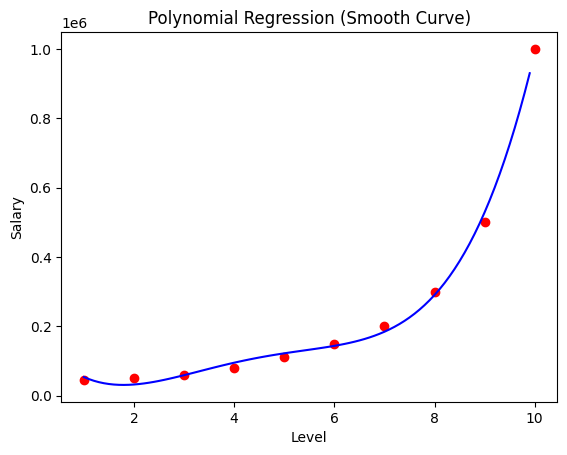

In [35]:
X_grid = np.arange(min(X), max(X), 0.1).reshape(-1,1)

plt.scatter(X,Y, color="red")
plt.plot(X_grid, modelPLR.predict(modelPR.transform(X_grid)), color="blue")
plt.title("Polynomial Regression (Smooth Curve)")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

### *Prediction using Polynomial Regression*

In [36]:
x = float(input("Enter Level of Employee: "))
salaryPred = modelPLR.predict(modelPR.transform([[x]]))
print("Predicted Salary for Level", x, "is", round(salaryPred[0],2))

Enter Level of Employee: 24
Predicted Salary for Level 24.0 is 131271439.39
